In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

path = "/content/drive/MyDrive/prob-1"

print(os.listdir(path))

Mounted at /content/drive
['Archive (1).zip']


In [2]:
from zipfile import ZipFile

zip_path = "/content/drive/MyDrive/prob-1/Archive (1).zip"
extract_path = "/content/drive/MyDrive/prob-1"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Complete")

Extraction Complete


In [3]:
import os

path = "/content/drive/MyDrive/prob-1"

print(os.listdir(path))

['Archive (1).zip', 'test', '__MACOSX', 'train', 'val']


In [5]:
import os

base_path = "/content/drive/MyDrive/prob-1"

print("Train:", os.listdir(base_path + "/train"))
print("Test:", os.listdir(base_path + "/test"))
print("Validation:", os.listdir(base_path + "/val"))

Train: ['.DS_Store', 'PNEUMONIA', 'NORMAL']
Test: ['.DS_Store', 'PNEUMONIA', 'NORMAL']
Validation: ['PNEUMONIA', 'NORMAL']


# Pneumonia Detection from Chest X-Ray Images Using CNN

### Problem Set 01

This project develops a Convolutional Neural Network (CNN) model
to classify chest X-ray images into two categories:

- Normal
- Pneumonia

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [8]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
base_dir = "/content/drive/MyDrive/prob-1"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

print("Train Path:", train_dir)
print("Validation Path:", val_dir)
print("Test Path:", test_dir)

Train Path: /content/drive/MyDrive/prob-1/train
Validation Path: /content/drive/MyDrive/prob-1/val
Test Path: /content/drive/MyDrive/prob-1/test


In [10]:
print("Train folders:", os.listdir(train_dir))
print("Validation folders:", os.listdir(val_dir))
print("Test folders:", os.listdir(test_dir))

Train folders: ['.DS_Store', 'PNEUMONIA', 'NORMAL']
Validation folders: ['PNEUMONIA', 'NORMAL']
Test folders: ['.DS_Store', 'PNEUMONIA', 'NORMAL']


In [11]:
def count_images(folder):
    normal_count = len([
        f for f in os.listdir(os.path.join(folder, "NORMAL"))
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    pneumonia_count = len([
        f for f in os.listdir(os.path.join(folder, "PNEUMONIA"))
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    return normal_count, pneumonia_count


train_normal, train_pneumonia = count_images(train_dir)
val_normal, val_pneumonia = count_images(val_dir)
test_normal, test_pneumonia = count_images(test_dir)

print("TRAIN")
print("Normal:", train_normal)
print("Pneumonia:", train_pneumonia)

print("\nVALIDATION")
print("Normal:", val_normal)
print("Pneumonia:", val_pneumonia)

print("\nTEST")
print("Normal:", test_normal)
print("Pneumonia:", test_pneumonia)

TRAIN
Normal: 1341
Pneumonia: 3875

VALIDATION
Normal: 8
Pneumonia: 8

TEST
Normal: 234
Pneumonia: 390


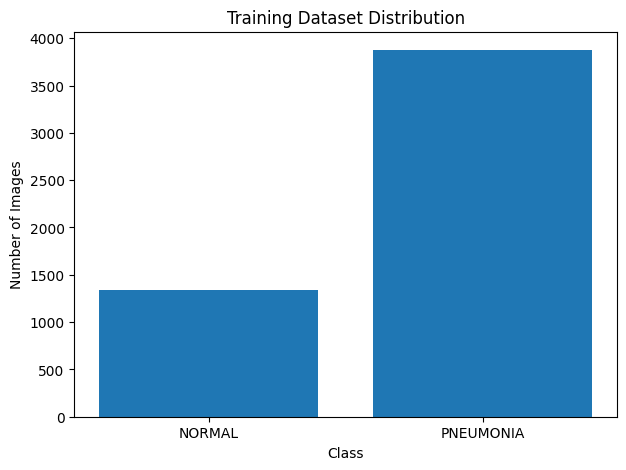

In [12]:
train_labels = ['NORMAL', 'PNEUMONIA']
train_counts = [train_normal, train_pneumonia]

plt.figure(figsize=(7,5))

plt.bar(train_labels, train_counts)

plt.title("Training Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

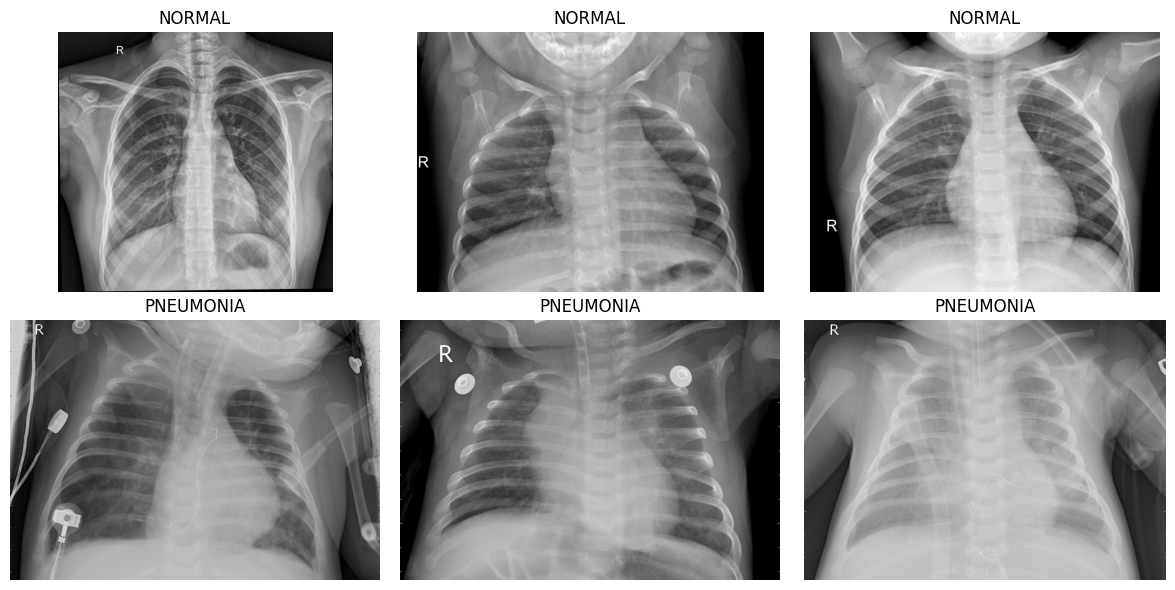

In [13]:
normal_folder = os.path.join(train_dir, "NORMAL")
pneumonia_folder = os.path.join(train_dir, "PNEUMONIA")

normal_images = [
    f for f in os.listdir(normal_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

pneumonia_images = [
    f for f in os.listdir(pneumonia_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

plt.figure(figsize=(12,6))

for i in range(3):
    img = plt.imread(os.path.join(normal_folder, normal_images[i]))

    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap='gray')
    plt.title("NORMAL")
    plt.axis("off")

for i in range(3):
    img = plt.imread(os.path.join(pneumonia_folder, pneumonia_images[i]))

    plt.subplot(2,3,i+4)
    plt.imshow(img, cmap='gray')
    plt.title("PNEUMONIA")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
from PIL import Image

sample_path = os.path.join(
    normal_folder,
    normal_images[0]
)

img = Image.open(sample_path)

print("Original Image Size:", img.size)
print("Image Mode:", img.mode)

Original Image Size: (2359, 2234)
Image Mode: L


In [15]:
IMG_SIZE = 150
BATCH_SIZE = 32

print("Image Size:", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)

Image Size: 150
Batch Size: 32


In [16]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    shear_range=0.15,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Data augmentation configured successfully.")

Data augmentation configured successfully.


In [17]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

Found 5216 images belonging to 2 classes.


In [18]:
val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 16 images belonging to 2 classes.


In [19]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [20]:
print("Class Indices:")
print(train_generator.class_indices)

Class Indices:
{'NORMAL': 0, 'PNEUMONIA': 1}


In [21]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [24]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "/content/best_pneumonia_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

print("Callbacks configured successfully.")

Callbacks configured successfully.


In [25]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.7977 - loss: 0.4346 - val_accuracy: 0.8750 - val_loss: 0.4566
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.8932 - loss: 0.2605 - val_accuracy: 0.8125 - val_loss: 0.4738
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.9013 - loss: 0.2394 - val_accuracy: 0.7500 - val_loss: 0.6694
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.9168 - loss: 0.2116 - val_accuracy: 0.7500 - val_loss: 0.7437


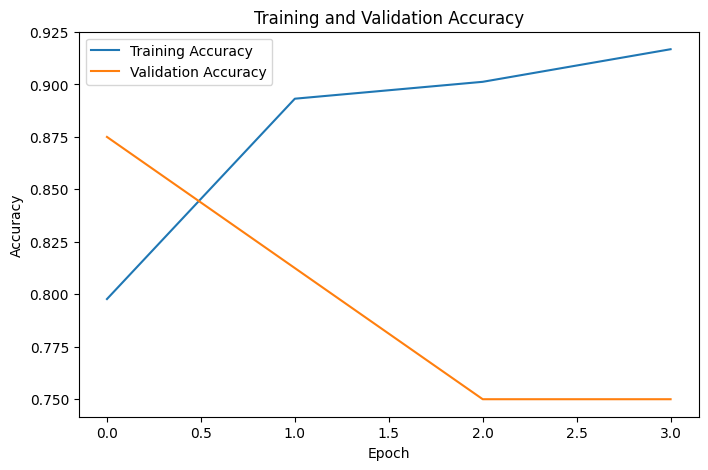

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

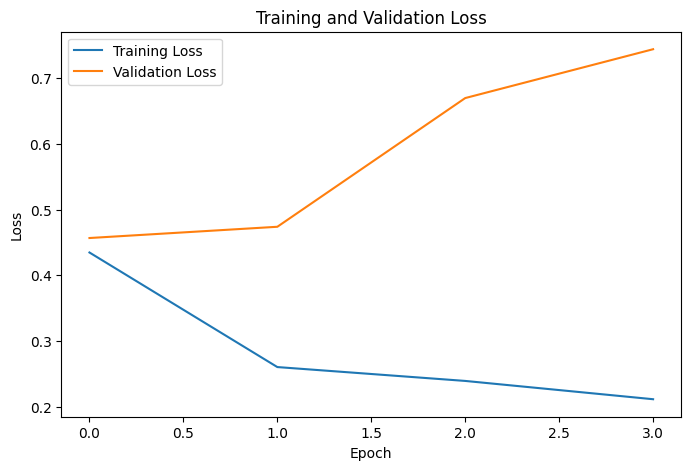

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [28]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 731ms/step - accuracy: 0.8013 - loss: 0.4061
Test Loss: 0.4061339497566223
Test Accuracy: 0.8012820482254028


In [29]:
test_generator.reset()

probabilities = model.predict(test_generator)

predictions = (probabilities >= 0.5).astype(int).flatten()

true_labels = test_generator.classes

print("Predictions generated successfully.")
print("Number of predictions:", len(predictions))

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 715ms/step
Predictions generated successfully.
Number of predictions: 624


In [30]:
cm = confusion_matrix(true_labels, predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[123 111]
 [ 13 377]]


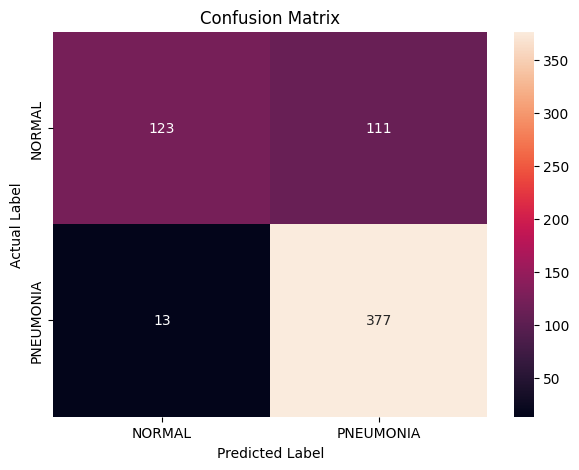

In [31]:
plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [32]:
report = classification_report(
    true_labels,
    predictions,
    target_names=['NORMAL', 'PNEUMONIA']
)

print(report)

              precision    recall  f1-score   support

      NORMAL       0.90      0.53      0.66       234
   PNEUMONIA       0.77      0.97      0.86       390

    accuracy                           0.80       624
   macro avg       0.84      0.75      0.76       624
weighted avg       0.82      0.80      0.79       624



In [33]:
accuracy = accuracy_score(true_labels, predictions)

precision = precision_score(
    true_labels,
    predictions
)

recall = recall_score(
    true_labels,
    predictions
)

f1 = f1_score(
    true_labels,
    predictions
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8012820512820513
Precision: 0.7725409836065574
Recall   : 0.9666666666666667
F1 Score : 0.8587699316628702


In [34]:
model.save(
    "/content/drive/MyDrive/prob-1/pneumonia_cnn_model.keras"
)

print("Model saved successfully.")

Model saved successfully.


In [35]:
from tensorflow.keras.utils import load_img, img_to_array

image_path = os.path.join(
    pneumonia_folder,
    pneumonia_images[0]
)

image = load_img(
    image_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

image_array = img_to_array(image)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_array)[0][0]

if prediction >= 0.5:
    result = "PNEUMONIA"
else:
    result = "NORMAL"

print("Predicted Class:", result)
print("Prediction Probability:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
Predicted Class: PNEUMONIA
Prediction Probability: 0.99091035


## Findings

The CNN model was trained to classify chest X-ray images into two classes: Normal and Pneumonia.

The images were resized to 150 × 150 pixels and pixel values were normalized to the range 0 to 1. Data augmentation techniques such as rotation, zooming, shearing, and horizontal flipping were applied to the training images.

The CNN model used convolutional layers, max-pooling layers, a fully connected layer, dropout, and a sigmoid output layer for binary classification.

The model was evaluated using the test dataset. The obtained test loss was 0.4061 and the test accuracy was 80.13%.

### Test Results

* Test Accuracy: **80.13%**
* Precision: **77.25%**
* Recall: **96.67%**
* F1 Score: **85.88%**

The confusion matrix was:

```text
[[123 111]
 [ 13 377]]
```

This shows that the model correctly classified 123 Normal images and 377 Pneumonia images. It incorrectly classified 111 Normal images as Pneumonia and 13 Pneumonia images as Normal.

The high recall of 96.67% indicates that the model was able to correctly identify most of the Pneumonia images in the test dataset.

Overall, the CNN successfully learned visual patterns from the chest X-ray images and performed binary classification between Normal and Pneumonia classes.


## Conclusion

A Convolutional Neural Network was successfully developed to classify chest X-ray images into Normal and Pneumonia classes.

The dataset was divided into training, validation, and testing sets. Image preprocessing and data augmentation were applied before training the CNN model.

The model achieved a test accuracy of **80.13%**, with a precision of **77.25%**, recall of **96.67%**, and F1-score of **85.88%**.

The results demonstrate that CNNs can learn useful visual patterns from chest X-ray images and perform binary image classification effectively.

However, this model was developed for academic purposes only and should not be considered a clinical diagnostic system.
